In [35]:
import numpy as np
import pandas as pd

In [36]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [37]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
190,spam,Are you unique enough? Find out from 30th Augu...,NaN,NaN,NaN
4112,ham,Thought we could go out for dinner. I'll treat...,NaN,NaN,NaN
4836,ham,....photoshop makes my computer shut down.,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
2397,ham,Neshanth..tel me who r u?,NaN,NaN,NaN


In [38]:
df.shape

(5572, 5)

In [39]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [41]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [42]:
df.sample(5)

,v1,v2
3587,ham,If you were/are free i can give. Otherwise nal...
5012,ham,"Uncle G, just checking up on you. Do have a re..."
427,ham,Any pain on urination any thing else?
2723,ham,"Tunde, how are you doing. This is just wishing..."
2887,ham,I take it we didn't have the phone callon Frid...


In [43]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
2383,ham,Your pussy is perfect!
4472,ham,S but not able to sleep.
4603,ham,THANX 4 PUTTIN DA FONE DOWN ON ME!!
2890,ham,"Yeah there's quite a bit left, I'll swing by t..."
4852,ham,I'm fine. Hope you are also


In [44]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [45]:
df['target'] = encoder.fit_transform(df['target'])

In [46]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [47]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [48]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [49]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.shape

(5169, 2)

## 2.EDA

In [52]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [53]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

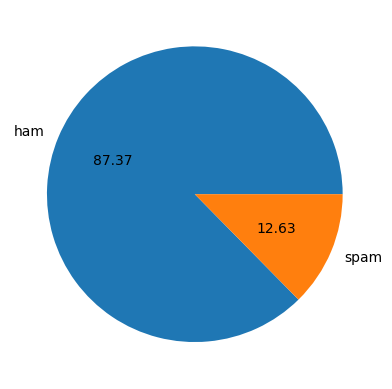

In [54]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [55]:
# Data is imbalanced

In [56]:
import nltk

In [57]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sinha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [58]:
!pip install nltk


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sinha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [60]:
df['num_characters'] = df['text'].apply(len)

In [61]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [62]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [63]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [64]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [65]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [66]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [67]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [68]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [69]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

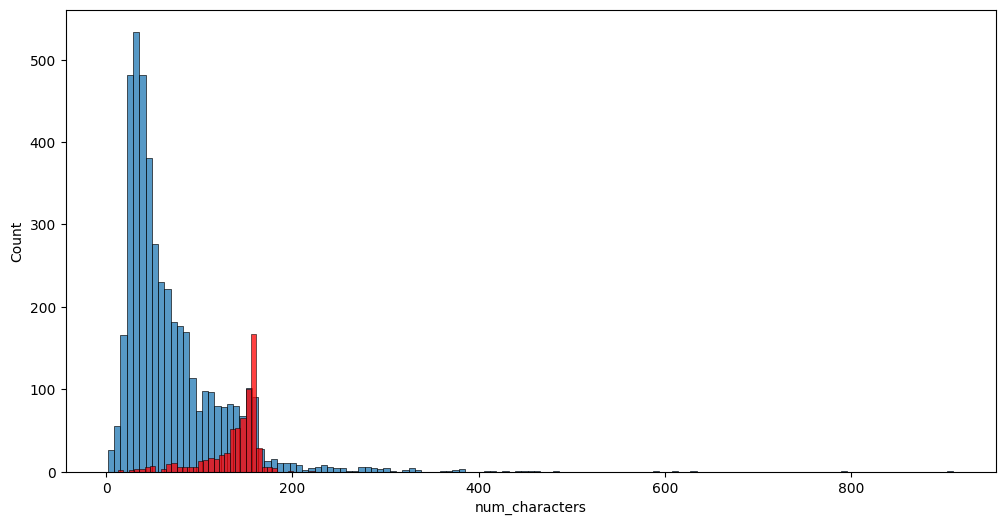

In [70]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

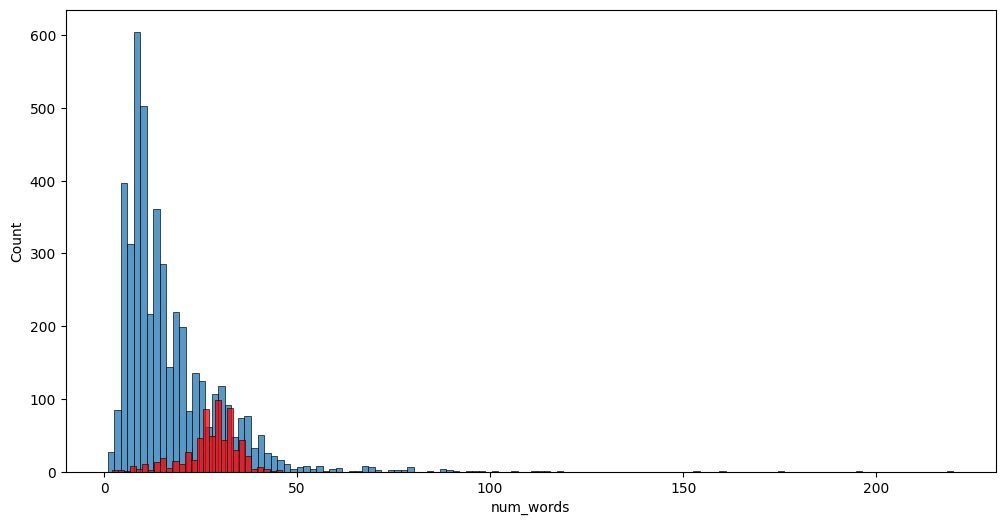

In [71]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

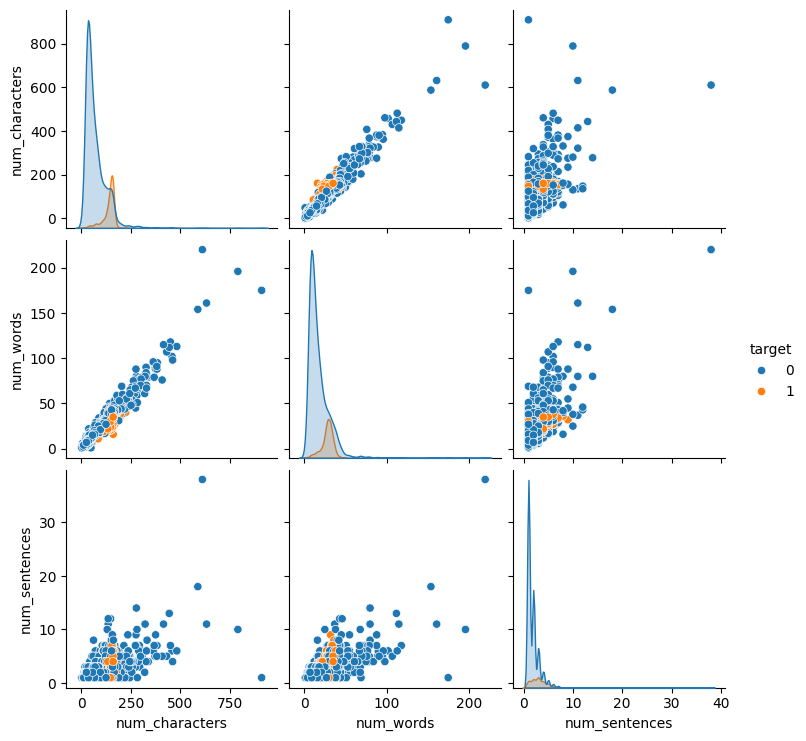

In [296]:
print(sns.pairplot(df,hue='target'))

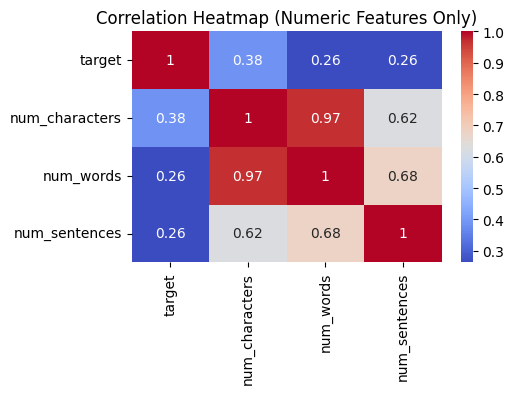

In [73]:
corr = df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [79]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [78]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('loving')

'love'

In [80]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [82]:
import string 


In [83]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [85]:
df['transformed_text']=df['text'].apply(transform_text)

In [86]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [87]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [88]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

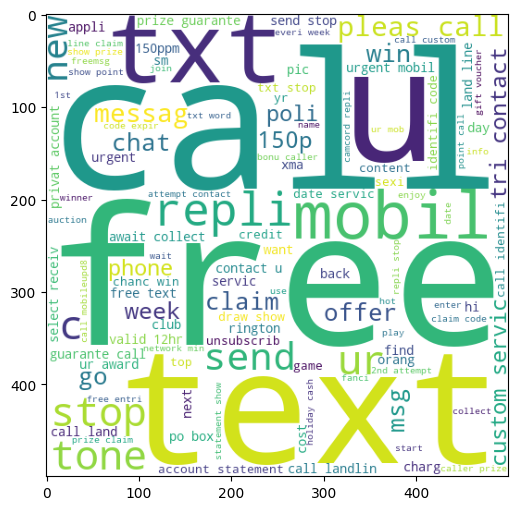

In [89]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [90]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

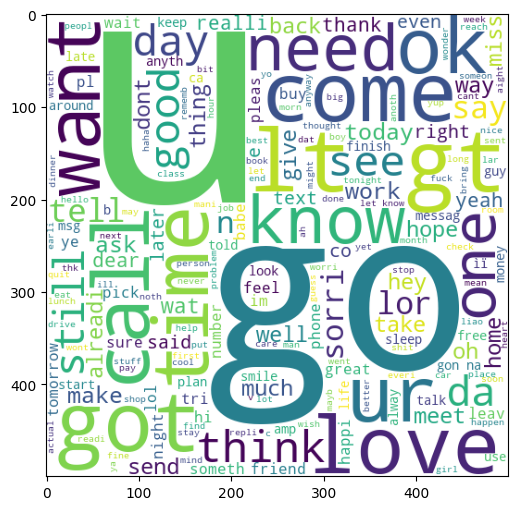

In [91]:

plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [92]:
df.head()


,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [93]:

spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [95]:
len(spam_corpus)

9939

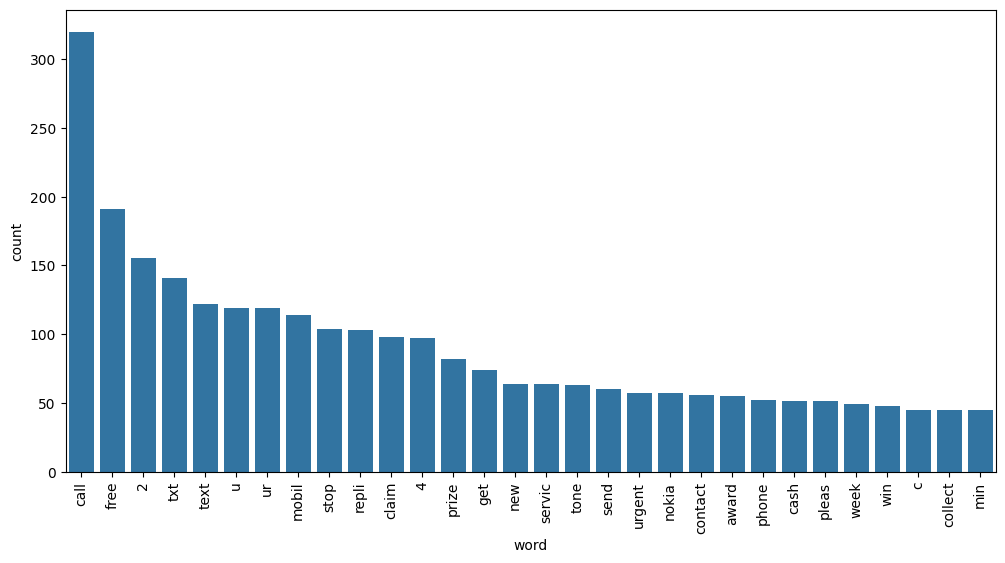

In [102]:
from collections import Counter
import matplotlib.pyplot as plt

# Get the 30 most common words and their counts
common_spam = Counter(spam_corpus).most_common(30)

# Create a DataFrame
mostCommonSPAM = pd.DataFrame(common_spam, columns=['word', 'count'])

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=mostCommonSPAM, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

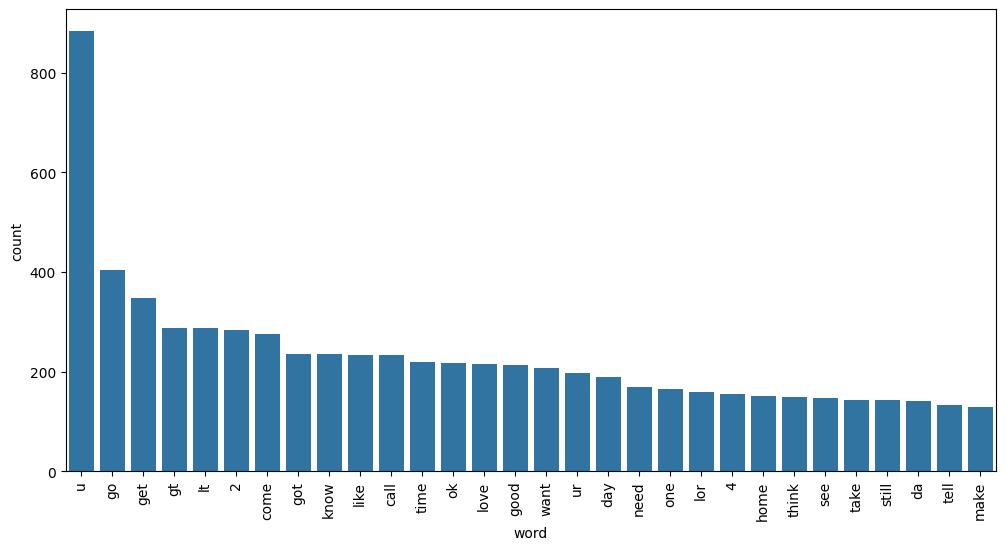

In [104]:
common_ham = Counter(ham_corpus).most_common(30)

# Create a DataFrame with appropriate column names
mostCommonHAM = pd.DataFrame(common_ham, columns=['word', 'count'])

# Plot barplot correctly
plt.figure(figsize=(12, 6))
sns.barplot(data=mostCommonHAM, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

In [105]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## MODEL BUILDING

In [226]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
from sklearn.model_selection import train_test_split


In [227]:
# Step 1: Define features and labels
X = df['transformed_text']
y = df['target']

In [228]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 49)

In [229]:
tfidf = TfidfVectorizer(max_features=3000)

In [230]:
X_train = tfidf.fit_transform(X_train).toarray()
X_test = tfidf.transform(X_test).toarray()


In [231]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4135, 3000)
X_test shape: (1034, 3000)


In [200]:
X.shape

(5169, 3000)

In [201]:
y=df['target'].values

In [202]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [261]:
type(X_train)

numpy.ndarray

In [232]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [283]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print("GaussianNB:")
print("Accuracy:", accuracy_score(y_test, y_pred1))
cm = confusion_matrix(y_test, y_pred1)   # confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print()


GaussianNB:
Accuracy: 0.8404255319148937
Confusion Matrix:
 [[754 145]
 [ 20 115]]
Precision: 0.4423076923076923



In [295]:
# Cross-validation
scores_gnb = cross_val_score(gnb, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation accuracy (GaussianNB):", scores_gnb.mean())

Cross-validation accuracy (GaussianNB): 0.879081015719468


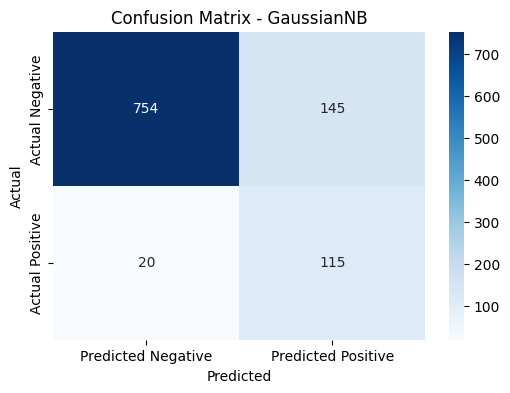

In [284]:
# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative','Predicted Positive'],
            yticklabels=['Actual Negative','Actual Positive'])

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - GaussianNB')
plt.show()


In [276]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print("MultinomialNB:")
print("Accuracy:", accuracy_score(y_test, y_pred2))
cm = confusion_matrix(y_test, y_pred2)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print()

MultinomialNB:
Accuracy: 0.9661508704061895
Confusion Matrix:
 [[898   1]
 [ 34 101]]
Precision: 0.9901960784313726



In [297]:
# Cross-validation
from sklearn.model_selection import cross_val_score
# Cross-validation
scores_mnb = cross_val_score(mnb, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation accuracy (MultinomialNB):", scores_mnb.mean())

Cross-validation accuracy (MultinomialNB): 0.9680773881499395


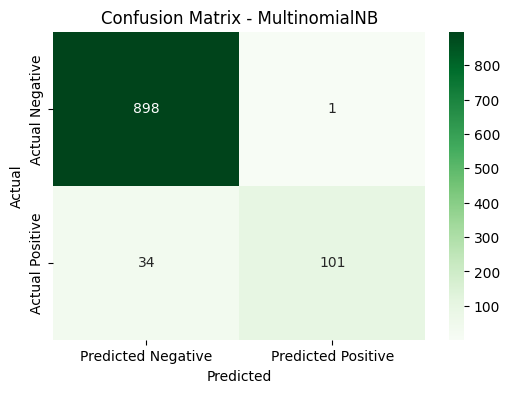

In [277]:
# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Negative','Predicted Positive'],
            yticklabels=['Actual Negative','Actual Positive'])

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - MultinomialNB')
plt.show()

In [281]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print("BernoulliNB:")
print("Accuracy:", accuracy_score(y_test, y_pred3))
cm = confusion_matrix(y_test, y_pred3)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))

BernoulliNB:
Accuracy: 0.9748549323017408
Confusion Matrix:
 [[899   0]
 [ 26 109]]
Precision: 1.0


In [293]:
# Cross-validation
from sklearn.model_selection import cross_val_score
# Cross-validation
scores_bnb = cross_val_score(bnb, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation accuracy (BernoulliNB):", scores_bnb.mean())

Cross-validation accuracy (BernoulliNB): 0.9767835550181377


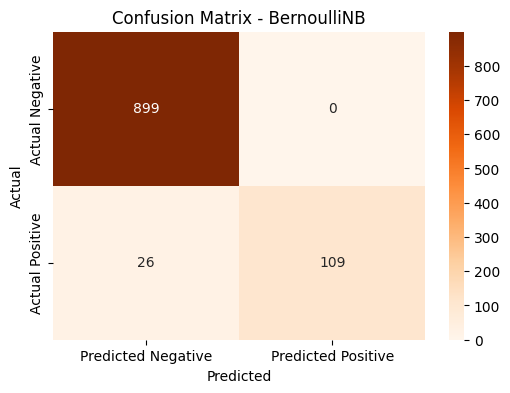

In [282]:
# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Negative','Predicted Positive'],
            yticklabels=['Actual Negative','Actual Positive'])

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - BernoulliNB')
plt.show()

In [237]:
#trying out different CLASSIFIER model for the BEST predictions
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [140]:
#creating objects of the classifier models
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)


In [141]:

#creating a dictionary that maps short names to the corresponding classification models.
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
}

In [142]:
#creating a function which uses train test split data and performing on model and returning the scores
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [238]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9709864603481625, 0.9565217391304348)

In [239]:
train_classifier(knc,X_train,y_train,X_test,y_test)

(0.9061895551257253, 0.975)

In [145]:
#taking each classifier algorithm, training and testing data, storing the score values and then printing for each
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    #calling the previously defined function
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)


For  SVC
Accuracy -  0.9294003868471954
Precision -  0.7672413793103449
For  KN
Accuracy -  0.90715667311412
Precision -  1.0
For  NB
Accuracy -  0.9700193423597679
Precision -  0.8768115942028986
For  DT
Accuracy -  0.9332688588007737
Precision -  0.9714285714285714
For  LR
Accuracy -  0.9661508704061895
Precision -  0.9545454545454546
For  RF
Accuracy -  0.965183752417795
Precision -  1.0
For  AdaBoost
Accuracy -  0.9177949709864603
Precision -  0.8571428571428571
For  BgC
Accuracy -  0.960348162475822
Precision -  0.9351851851851852
For  ETC
Accuracy -  0.9680851063829787
Precision -  1.0
For  GBDT
Accuracy -  0.9477756286266924
Precision -  0.9879518072289156


In [146]:
#converting the accuracy and precision score values to a dataframe
#sorting on the basis of precision value
performance = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)


In [147]:
performance

,Algorithm,Accuracy,Precision
1,KN,0.907157,1.000000
5,RF,0.965184,1.000000
8,ETC,0.968085,1.000000
9,GBDT,0.947776,0.987952
3,DT,0.933269,0.971429
4,LR,0.966151,0.954545
7,BgC,0.960348,0.935185
2,NB,0.970019,0.876812
6,AdaBoost,0.917795,0.857143
0,SVC,0.929400,0.767241


In [148]:
performance_df1 = pd.melt(performance, id_vars = "Algorithm")


In [149]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.907157
1,RF,Accuracy,0.965184
2,ETC,Accuracy,0.968085
3,GBDT,Accuracy,0.947776
4,DT,Accuracy,0.933269
5,LR,Accuracy,0.966151
6,BgC,Accuracy,0.960348
7,NB,Accuracy,0.970019
8,AdaBoost,Accuracy,0.917795
9,SVC,Accuracy,0.929400


In [150]:
#precision is 1, we need to maximize the accuracy score.
#try using the Voting classifier

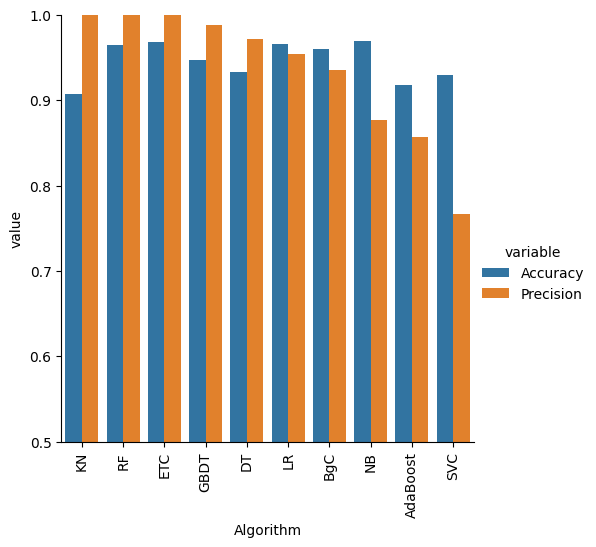

In [151]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [152]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [240]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [241]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [242]:
new_df = performance.merge(temp_df,on='Algorithm')

In [243]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [244]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [245]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.907157,1.000000,0.907157,1.000000,0.907157,1.000000,0.907157,1.000000
1,RF,0.965184,1.000000,0.965184,1.000000,0.965184,1.000000,0.965184,1.000000
2,ETC,0.968085,1.000000,0.968085,1.000000,0.968085,1.000000,0.968085,1.000000
3,GBDT,0.947776,0.987952,0.947776,0.987952,0.947776,0.987952,0.947776,0.987952
4,DT,0.933269,0.971429,0.933269,0.971429,0.933269,0.971429,0.933269,0.971429
5,LR,0.966151,0.954545,0.966151,0.954545,0.966151,0.954545,0.966151,0.954545
6,BgC,0.960348,0.935185,0.960348,0.935185,0.960348,0.935185,0.960348,0.935185
7,NB,0.970019,0.876812,0.970019,0.876812,0.970019,0.876812,0.970019,0.876812
8,AdaBoost,0.917795,0.857143,0.917795,0.857143,0.917795,0.857143,0.917795,0.857143
9,SVC,0.929400,0.767241,0.929400,0.767241,0.929400,0.767241,0.929400,0.767241


In [246]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [247]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [248]:
#training the data
voting.fit(X_train,y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [249]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))


Accuracy 0.9787234042553191
Precision 1.0


Confusion Matrix:
 [[898   1]
 [ 15 120]]


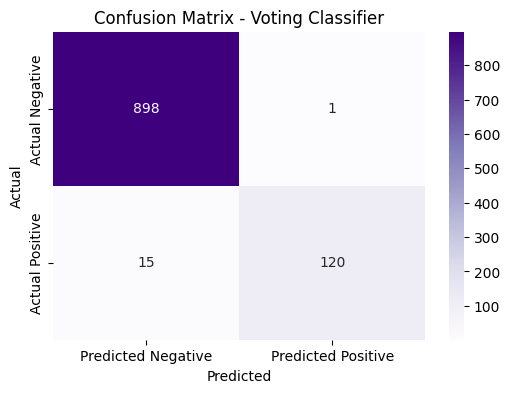

In [286]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Negative','Predicted Positive'],
            yticklabels=['Actual Negative','Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Voting Classifier')
plt.show()

In [ ]:
#precision is still 1 but accuracy dropped down.

In [250]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [251]:
from sklearn.ensemble import StackingClassifier

In [252]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)


In [253]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9845261121856866
Precision 0.9917355371900827


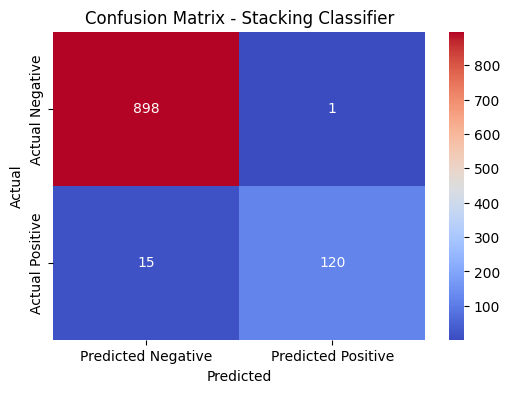

In [287]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Predicted Negative','Predicted Positive'],
            yticklabels=['Actual Negative','Actual Positive'])

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Stacking Classifier')
plt.show()

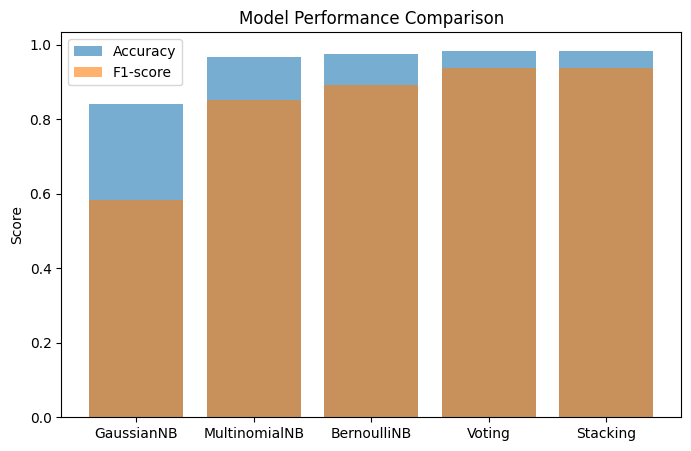

In [290]:
from sklearn.metrics import f1_score

models = ['GaussianNB','MultinomialNB','BernoulliNB','Voting','Stacking']
accuracies = [accuracy_score(y_test,y_pred1),
              accuracy_score(y_test,y_pred2),
              accuracy_score(y_test,y_pred3),
              accuracy_score(y_test,y_pred),
              accuracy_score(y_test,y_pred)]

f1_scores = [f1_score(y_test,y_pred1),
             f1_score(y_test,y_pred2),
             f1_score(y_test,y_pred3),
             f1_score(y_test,y_pred),
             f1_score(y_test,y_pred)]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, alpha=0.6, label='Accuracy')
plt.bar(models, f1_scores, alpha=0.6, label='F1-score')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()


In [269]:
#we will pickle 2 files
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))
print("✅ Model and vectorizer saved successfully!")


✅ Model and vectorizer saved successfully!
